In [1]:
# ============================================================
# NOTEBOOK 03 — CLUSTERING NO SUPERVISADO (K-Means)
# ============================================================

# CONTEXTO:
# En el Notebook 02 construimos un modelo supervisado que predice
# si un envío llegará tarde usando el target (Reached.on.Time_Y.N).
# Ahora cambiamos completamente de enfoque:

# APRENDIZAJE NO SUPERVISADO:
# El modelo NO conoce si los envíos llegaron tarde o no.
# Solo ve las características del envío (peso, descuento, coste...)
# y encuentra por sí solo grupos de envíos que se parecen entre sí.
# Nosotros solo descubrimos después qué tasa de retraso tiene cada grupo.

# ¿POR QUÉ K-Means?
# K-Means es el algoritmo de clustering más utilizado.
# Agrupa los datos en K clusters intentando que cada envío
# quede asignado al grupo cuyo centro (centroide) le queda más cerca.
# Es iterativo: empieza con centroides aleatorios y los va ajustando
# hasta que los grupos se estabilizan.

# OBJETIVO DE NEGOCIO:
# Descubrir si existen perfiles naturales de envío en el dataset.
# Si encontramos un cluster con alta tasa de retraso y características
# comunes (peso alto, descuento elevado, coste alto...), la empresa
# puede identificar esos envíos en el momento del empaquetado y
# tomar medidas preventivas antes incluso de que salgan del almacén.

# HOJA DE RUTA:
#   1. PREPARACIÓN DE DATOS
#      - Cargar el dataset original
#      - Seleccionar solo variables numéricas originales
#      - Eliminar el target (el modelo no puede verlo)
#      - Escalar las variables (K-Means es muy sensible a la escala)

#   2. ELECCIÓN DEL NÚMERO DE CLUSTERS (K)
#      - Método del Codo (Elbow Method): detectar el K óptimo por inercia
#      - Índice de Silhouette: validar la calidad de los clusters

#   3. ENTRENAMIENTO DEL MODELO K-Means con K=3

#   4. ANÁLISIS DE LOS CLUSTERS
#      - Perfil de cada cluster: ¿qué características tienen?
#      - Tasa de retraso por cluster: ¿cuál es el más peligroso?
#      - Visualización con PCA (reducción a 2D para poder dibujar los grupos)

#   5. CONCLUSIÓN DE NEGOCIO
#      - ¿Qué nos dicen los clusters sobre cómo opera la empresa?
#      - ¿Cómo complementa esto al modelo supervisado del Notebook 02?

## Bloque 1: Librerías y carga de datos

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# preprocesamiento
from sklearn.preprocessing import StandardScaler  # escalar variables (obligatorio en K-Means)
from sklearn.decomposition import PCA             # reducción de dimensiones para visualizar clusters en 2D

# modelo
from sklearn.cluster import KMeans

# métricas de evaluación del clustering
from sklearn.metrics import silhouette_score  # mide qué tan bien definidos están los clusters

import warnings
warnings.filterwarnings('ignore')

print('✅ Librerías cargadas')

✅ Librerías cargadas


## Bloque 2: Preparación de datos para clustering

In [3]:
df = pd.read_csv('../data/shipping_data.csv')

# ============================================================
# DECISIÓN IMPORTANTE: qué variables usamos para el clustering
# ============================================================
# En el Notebook 02 usamos todas las variables incluyendo las dummies
# (Warehouse_block, Mode_of_Shipment, Gender convertidas a 0/1).
# Para el clustering usamos solo las 7 variables numéricas originales.
#
# ¿Por qué?
# K-Means mide distancias entre puntos. Las variables numéricas continuas
# (peso, descuento, coste...) aportan información rica sobre las diferencias
# entre envíos. Las dummies binarias (0/1) aportan menos señal métrica
# y pueden distorsionar los clusters hacia agrupaciones por almacén o
# modo de envío en lugar de por perfil de riesgo, que es lo que nos interesa.

cols_cluster = [
    'Weight_in_gms',        # peso del paquete
    'Discount_offered',     # descuento aplicado
    'Cost_of_the_Product',  # coste del producto
    'Customer_care_calls',  # llamadas al servicio de atención
    'Customer_rating',      # valoración del cliente
    'Prior_purchases',      # compras previas del cliente
    'Product_importance'    # importancia del producto (ya codificada como 1/2/3 en el nb02)
]

# Codificamos Product_importance igual que en el notebook 02
mapa_imp = {'low': 1, 'medium': 2, 'high': 3}
df['Product_importance'] = df['Product_importance'].map(mapa_imp)

# Separamos el target ANTES de entrenar: el modelo no puede verlo
# Lo guardaremos para analizarlo DESPUÉS de hacer los clusters
target = df['Reached.on.Time_Y.N']
X_cluster = df[cols_cluster]

print(f'Variables para clustering: {cols_cluster}')
print(f'Shape: {X_cluster.shape}')
print()
print('Vista previa:')
display(X_cluster.head())

Variables para clustering: ['Weight_in_gms', 'Discount_offered', 'Cost_of_the_Product', 'Customer_care_calls', 'Customer_rating', 'Prior_purchases', 'Product_importance']
Shape: (10999, 7)

Vista previa:


,Weight_in_gms,Discount_offered,Cost_of_the_Product,Customer_care_calls,Customer_rating,Prior_purchases,Product_importance
0,1233,44,177,4,2,3,1
1,3088,59,216,4,5,2,1
2,3374,48,183,2,2,4,1
3,1177,10,176,3,3,4,2
4,2484,46,184,2,2,3,2


In [4]:
# ============================================================
# ESCALADO — PASO OBLIGATORIO EN K-Means
# ============================================================
# K-Means calcula distancias entre puntos para asignar cada envío
# al cluster más cercano. Si no escalamos, las variables con valores
# grandes dominarán completamente esa distancia:
#
# Weight_in_gms llega hasta 7.000
# Discount_offered llega hasta 65
# Customer_rating solo va de 1 a 5
#
# Sin escalar, el peso dominaría el 99% de la distancia y el modelo
# agruparía los envíos casi exclusivamente por peso, ignorando el resto.
# Con StandardScaler todas las variables quedan en la misma escala
# (media=0, desviación típica=1) y contribuyen por igual.

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cluster)

print('✅ Variables escaladas correctamente')
print(f'Shape tras escalado: {X_scaled.shape}')

✅ Variables escaladas correctamente
Shape tras escalado: (10999, 7)


## Bloque 3: Elección del número óptimo de clusters (K)

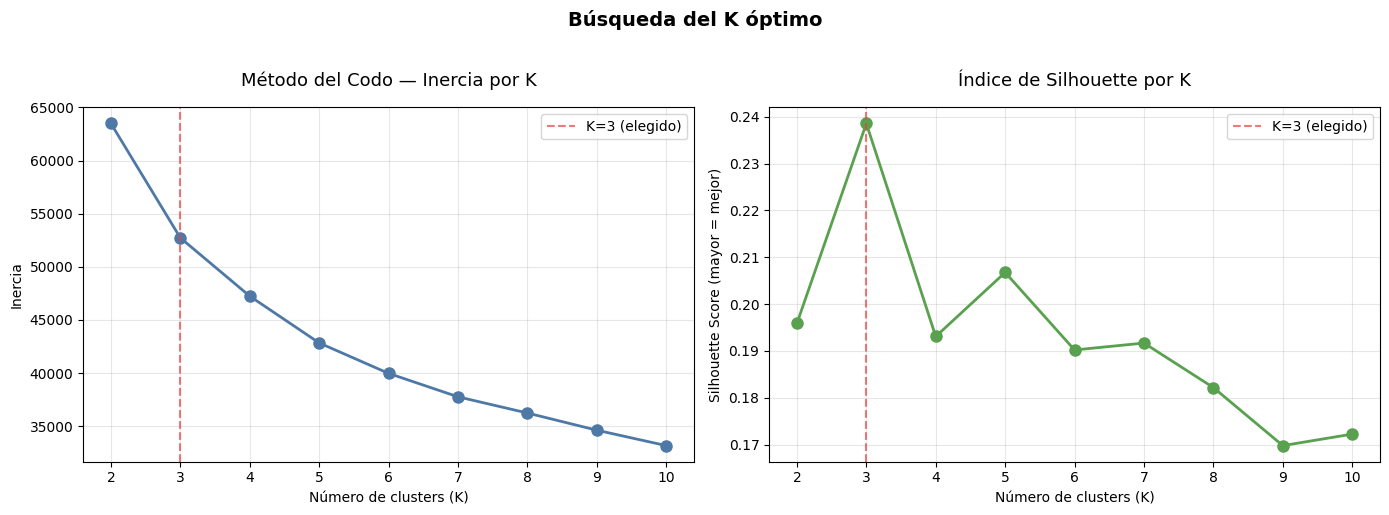

In [5]:
# ============================================================
# MÉTODO DEL CODO (Elbow Method)
# ============================================================
# El gran problema del K-Means es que hay que decirle cuántos grupos
# queremos ANTES de entrenarlo. Pero, ¿cómo sabemos cuántos son los correctos?
#
# El Método del Codo nos ayuda. Entrena el modelo con distintos valores de K
# y mide la INERCIA de cada uno:
#
# INERCIA = suma de las distancias de cada punto a su centroide más cercano.
# Cuanto menor sea la inercia, más compactos y bien definidos son los clusters.
#
# Siempre podríamos reducir la inercia a 0 poniendo K=número de filas
# (cada envío sería su propio cluster). Pero eso no tiene utilidad.
# Buscamos el punto donde añadir más clusters ya no reduce la inercia
# de forma significativa: ese 'codo' en la curva es el K óptimo.

inertias = []
silhouettes = []
K_range = range(2, 11)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_scaled, km.labels_))

# Graficamos los dos métodos juntos
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico 1: Método del Codo
axes[0].plot(K_range, inertias, marker='o', color='#4e79a7', linewidth=2, markersize=8)
axes[0].axvline(x=3, color='#e84040', linestyle='--', alpha=0.7, label='K=3 (elegido)')
axes[0].set_title('Método del Codo — Inercia por K', fontsize=13, pad=15)
axes[0].set_xlabel('Número de clusters (K)')
axes[0].set_ylabel('Inercia')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Gráfico 2: Índice de Silhouette
axes[1].plot(K_range, silhouettes, marker='o', color='#59a14f', linewidth=2, markersize=8)
axes[1].axvline(x=3, color='#e84040', linestyle='--', alpha=0.7, label='K=3 (elegido)')
axes[1].set_title('Índice de Silhouette por K', fontsize=13, pad=15)
axes[1].set_xlabel('Número de clusters (K)')
axes[1].set_ylabel('Silhouette Score (mayor = mejor)')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.suptitle('Búsqueda del K óptimo', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [6]:
# INTERPRETACIÓN — Método del Codo e Índice de Silhouette

# MÉTODO DEL CODO:
# La inercia baja de forma pronunciada de K=2 a K=3.
# A partir de K=3 la curva se aplana progresivamente: cada cluster adicional
# aporta menos reducción de inercia que el anterior.
# El 'codo' más claro se produce en K=3, que es donde la curva empieza
# a dejar de bajar con fuerza.

# ÍNDICE DE SILHOUETTE:
# Mide qué tan bien definido está cada punto dentro de su cluster
# (0.5 = muy bien definido, 0 = en la frontera entre dos clusters, negativo = mal asignado)
# El pico más alto se produce en K=3 (0.2386), lo que confirma que
# 3 clusters es la partición más natural de estos datos.
# Los valores generales son bajos (< 0.25) lo que es esperado en datasets
# con variables tan mezcladas como el nuestro: los clusters no son perfectamente
# compactos, pero sí son los grupos más diferenciados posibles.

# DECISIÓN: K = 3
# Ambos métodos apuntan a K=3 como el número óptimo de clusters.
# Además, 3 grupos tiene una interpretación de negocio clara:
# esperamos encontrar un perfil de alto riesgo, uno de bajo riesgo
# y uno intermedio.

print('K elegido: 3')
print(f'Silhouette score con K=3: {silhouettes[1]:.4f}')

K elegido: 3
Silhouette score con K=3: 0.2386


## Bloque 4: Entrenamiento del modelo K-Means

In [7]:
# ============================================================
# ENTRENAMIENTO K-Means con K=3
# ============================================================
# K-Means funciona así:
#   1. Coloca 3 centroides (puntos centrales) en posiciones aleatorias
#   2. Asigna cada envío al centroide más cercano
#   3. Recalcula la posición de cada centroide como la media de sus envíos asignados
#   4. Repite los pasos 2 y 3 hasta que los centroides dejan de moverse
#
# n_init=10 significa que repite todo el proceso 10 veces con centroides
# iniciales distintos y se queda con la mejor solución.
# Esto evita quedarse atrapado en un mínimo local por mala inicialización.

kmeans = KMeans(
    n_clusters=3,   # número de grupos
    random_state=42,
    n_init=10       # 10 inicializaciones distintas, nos quedamos con la mejor
)

# .fit_predict() entrena el modelo y asigna cada envío a un cluster (0, 1 o 2)
labels = kmeans.fit_predict(X_scaled)

# Añadimos el cluster y el target al dataframe para analizar
df_analisis = X_cluster.copy()
df_analisis['Cluster'] = labels
df_analisis['Retraso'] = target.values

print('✅ K-Means entrenado con K=3')
print()
print('Distribución de envíos por cluster:')
print(df_analisis['Cluster'].value_counts().sort_index())

✅ K-Means entrenado con K=3

Distribución de envíos por cluster:
Cluster
0    2294
1    6097
2    2608
Name: count, dtype: int64


## Bloque 5: Análisis de los clusters

TASA DE RETRASO POR CLUSTER:
         Tamaño  Tasa_retraso_%
Cluster                        
0          2294            99.5
1          6097            47.9
2          2608            52.3



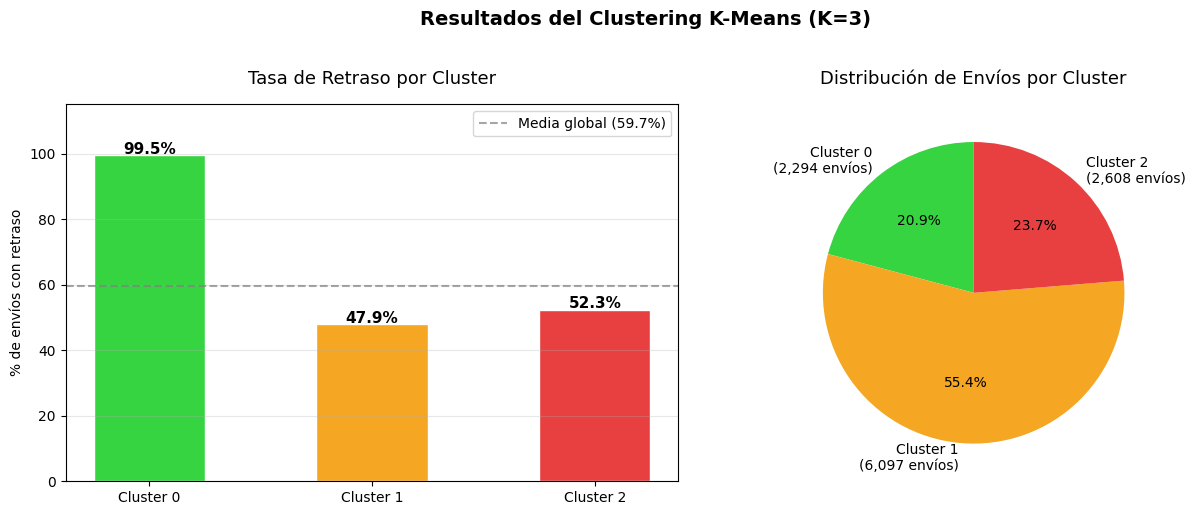

In [8]:
# ============================================================
# TASA DE RETRASO POR CLUSTER
# ============================================================
# Aquí está el momento clave: revelamos el target que el modelo
# no conocía y vemos si los grupos que encontró tienen tasas de
# retraso distintas. Si los clusters son útiles, deberían separar
# envíos con distinto nivel de riesgo.

tasa_retraso = df_analisis.groupby('Cluster')['Retraso'].mean() * 100
tamanio = df_analisis['Cluster'].value_counts().sort_index()

resumen = pd.DataFrame({
    'Tamaño': tamanio,
    'Tasa_retraso_%': tasa_retraso.round(1)
})

print('TASA DE RETRASO POR CLUSTER:')
print(resumen.to_string())
print()

# Visualización
colores_clusters = ['#37d442', '#f5a623', '#e84040']
etiquetas = ['Cluster 0', 'Cluster 1', 'Cluster 2']

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Tasa de retraso
bars = axes[0].bar(etiquetas, tasa_retraso.values, color=colores_clusters, edgecolor='white', width=0.5)
axes[0].axhline(y=59.7, color='gray', linestyle='--', alpha=0.7, label='Media global (59.7%)')
for bar in bars:
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.5,
                 f'{bar.get_height():.1f}%',
                 ha='center', fontweight='bold', fontsize=11)
axes[0].set_title('Tasa de Retraso por Cluster', fontsize=13, pad=15)
axes[0].set_ylabel('% de envíos con retraso')
axes[0].set_ylim(0, 115)
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

# Tamaño de clusters
axes[1].pie(
    tamanio.values,
    labels=[f'Cluster {i}\n({v:,} envíos)' for i, v in enumerate(tamanio.values)],
    colors=colores_clusters,
    autopct='%1.1f%%',
    startangle=90,
    textprops={'fontsize': 10}
)
axes[1].set_title('Distribución de Envíos por Cluster', fontsize=13, pad=15)

plt.suptitle('Resultados del Clustering K-Means (K=3)', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [ ]:
# INTERPRETACIÓN — Tasa de retraso por cluster

# El resultado es muy revelador. El K-Means, sin ver ni una sola etiqueta
# de retraso, ha conseguido separar los envíos en grupos con tasas
# de retraso radicalmente distintas:

# 🟢 CLUSTER 0 — 2.294 envíos — Tasa de retraso: 99.5%
#    El grupo de MÁXIMO RIESGO. Prácticamente el 100% de estos envíos
#    llegan tarde. El modelo los ha agrupado porque comparten unas
#    características muy específicas que los hacen casi inevitablemente
#    problemáticos. Veremos cuáles en el perfil.

# 🟡 CLUSTER 1 — 6.097 envíos — Tasa de retraso: 47.9%
#    El grupo MAYORITARIO y de BAJO RIESGO relativo. Con una tasa
#    del 47.9%, está por debajo de la media global (59.7%).
#    Representa el perfil de envío más común y más manejable.

# 🔴 CLUSTER 2 — 2.608 envíos — Tasa de retraso: 52.3%
#    El grupo INTERMEDIO. Ligeramente por debajo de la media global.
#    Tiene características distintas al Cluster 1 pero sin la señal
#    de alarma extrema del Cluster 0.

# CONCLUSIÓN CLAVE:
# El Cluster 0 es el hallazgo más importante de este análisis.
# Representa el 20.9% de los envíos pero concentra prácticamente
# todos sus retrasos. Si la empresa pudiera identificar estos envíos
# antes de salir del almacén, podría actuar de forma preventiva
# en el 100% de los casos. Ahora veamos qué los caracteriza.

PERFIL MEDIO DE CADA CLUSTER:
         Weight_in_gms  Discount_offered  Cost_of_the_Product  Customer_care_calls  Customer_rating  Prior_purchases  Product_importance
Cluster                                                                                                                                 
0               2214.0              40.1                188.7                  3.7              3.0              3.1                 1.6
1               4801.5               5.9                201.4                  3.7              3.0              3.1                 1.6
2               2153.7               7.4                249.6                  5.2              3.0              5.1                 1.5


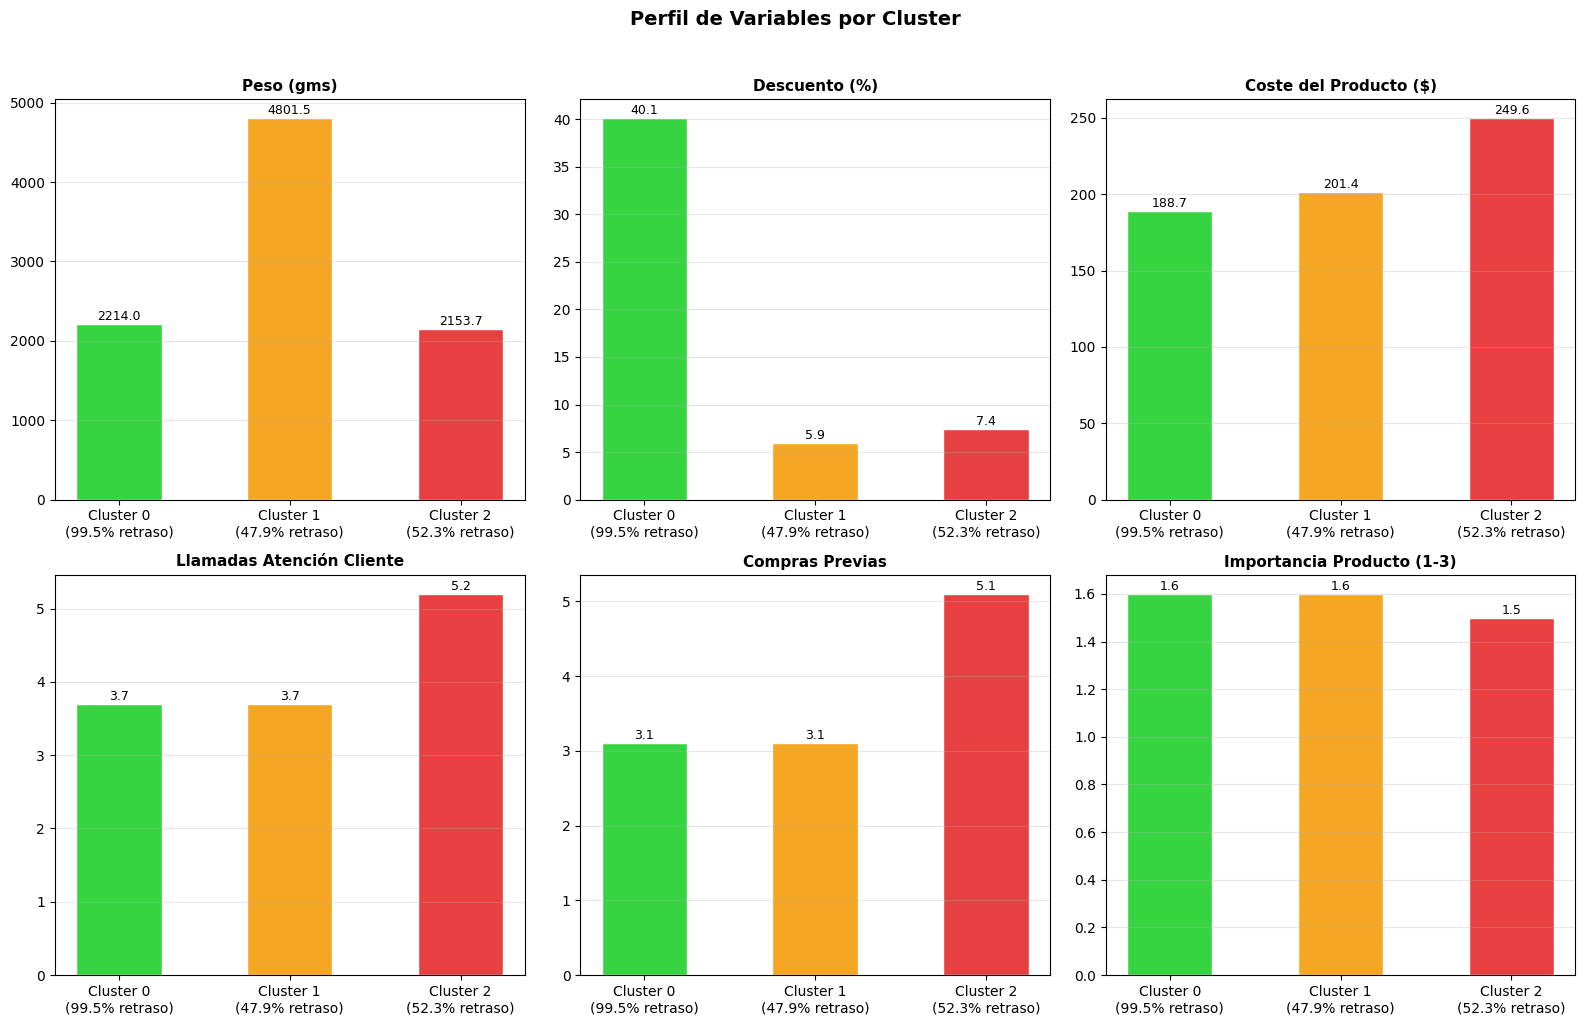

In [10]:
# ============================================================
# PERFIL DE CADA CLUSTER
# ============================================================
# Analizamos las medias de cada variable por cluster para entender
# qué características definen a cada grupo.

perfil = df_analisis.groupby('Cluster')[cols_cluster].mean().round(1)

print('PERFIL MEDIO DE CADA CLUSTER:')
print('='*75)
print(perfil.to_string())
print('='*75)

# Visualización del perfil con gráfico de barras agrupadas
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

variables_plot = ['Weight_in_gms', 'Discount_offered', 'Cost_of_the_Product',
                  'Customer_care_calls', 'Prior_purchases', 'Product_importance']

titulos = ['Peso (gms)', 'Descuento (%)', 'Coste del Producto ($)',
           'Llamadas Atención Cliente', 'Compras Previas', 'Importancia Producto (1-3)']

for ax, var, titulo in zip(axes, variables_plot, titulos):
    valores = perfil[var]
    bars = ax.bar(['Cluster 0\n(99.5% retraso)',
                   'Cluster 1\n(47.9% retraso)',
                   'Cluster 2\n(52.3% retraso)'],
                  valores,
                  color=colores_clusters,
                  edgecolor='white',
                  width=0.5)
    ax.set_title(titulo, fontsize=11, fontweight='bold')
    ax.grid(axis='y', alpha=0.3)
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + ax.get_ylim()[1]*0.01,
                f'{bar.get_height():.1f}',
                ha='center', fontsize=9)

plt.suptitle('Perfil de Variables por Cluster', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [11]:
# INTERPRETACIÓN — Perfil de los clusters

# Ahora entendemos por qué cada cluster tiene esa tasa de retraso.
# El perfil revela la identidad de cada grupo:

# 🟢 CLUSTER 0 — "EL GRUPO DEL DESCUENTO ALTO" (tasa de retraso: 99.5%)
#    La variable que define este cluster es el Discount_offered: media de 40.1%,
#    frente al 5.9% del Cluster 1 y el 7.4% del Cluster 2.
#    El descuento es 5-6 veces mayor que en los otros grupos.
#    Esto confirma matemáticamente el hallazgo más importante del EDA:
#    los descuentos altos saturan la capacidad logística y generan
#    retrasos casi garantizados. El peso y el coste son similares
#    a los otros grupos, lo que confirma que el descuento es el factor
#    determinante, no el tamaño o el valor del paquete.
#    → ACCIÓN: cualquier envío con descuento > 25% debe activar
#      automáticamente una alerta proactiva al cliente.

# 🟡 CLUSTER 1 — "EL GRUPO DEL PAQUETE PESADO" (tasa de retraso: 47.9%)
#    Define a los paquetes más pesados (media 4.801g, casi el doble que los otros).
#    A pesar de tener el mayor peso, tiene la tasa de retraso más baja (47.9%).
#    Esto es el hallazgo contraintuitivo que ya vimos en el Random Forest:
#    el peso por sí solo no determina el retraso. Es la combinación de
#    peso alto CON descuento alto la que dispara los problemas.
#    Este grupo tiene descuento bajo (5.9%), lo que lo mantiene bajo control.
#    → ACCIÓN: los paquetes pesados con descuento bajo son manejables.
#      No requieren atención prioritaria.

# 🔴 CLUSTER 2 — "EL GRUPO DEL CLIENTE FIDELIZADO" (tasa de retraso: 52.3%)
#    Lo que distingue a este cluster no es el peso ni el descuento,
#    sino el perfil del cliente: Prior_purchases media de 5.1 (vs 3.1 en los otros),
#    Customer_care_calls de 5.2 (vs 3.7 en los otros).
#    Son clientes con más historial de compras y que llaman más al servicio.
#    Esas llamadas pueden ser un indicador temprano de que algo va mal
#    en el proceso de entrega para estos perfiles de cliente.
#    → ACCIÓN: los clientes con más de 4 compras previas y más de 4 llamadas
#      al servicio merecen seguimiento especial de su envío.

Varianza explicada por los 2 componentes principales: 42.7%
  PC1: 23.3%
  PC2: 19.3%

Nota: un 23% de varianza explicada es bajo, lo que confirma
que los datos son multidimensionales y complejos.
El gráfico es una aproximación visual, no una representación exacta.


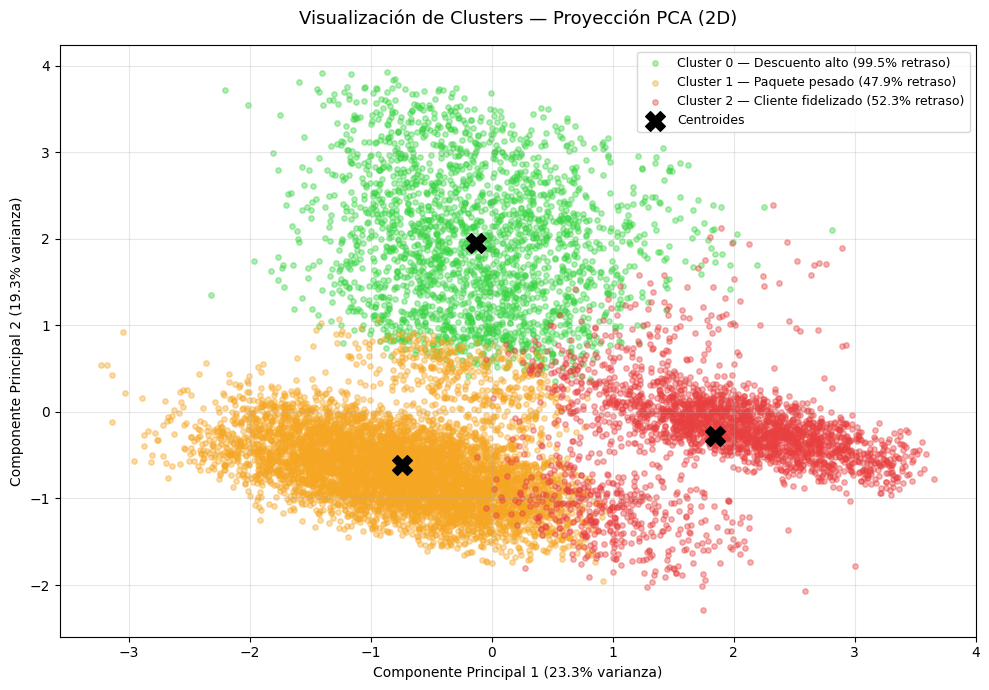

In [12]:
# ============================================================
# VISUALIZACIÓN CON PCA — los clusters en 2 dimensiones
# ============================================================
# Tenemos 7 variables, lo que hace imposible visualizar los clusters
# directamente. PCA (Análisis de Componentes Principales) reduce esas
# 7 dimensiones a 2 manteniendo la máxima varianza posible,
# permitiéndonos dibujar los clusters en un gráfico 2D.
#
# Importante: PCA no cambia los clusters, solo los proyecta en 2D
# para que podamos verlos. Es una herramienta de visualización, no de modelado.

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

varianza_total = sum(pca.explained_variance_ratio_)
print(f'Varianza explicada por los 2 componentes principales: {varianza_total:.1%}')
print(f'  PC1: {pca.explained_variance_ratio_[0]:.1%}')
print(f'  PC2: {pca.explained_variance_ratio_[1]:.1%}')
print()
print('Nota: un 23% de varianza explicada es bajo, lo que confirma')
print('que los datos son multidimensionales y complejos.')
print('El gráfico es una aproximación visual, no una representación exacta.')

# Gráfico de los clusters en 2D
df_pca = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])
df_pca['Cluster'] = labels

fig, ax = plt.subplots(figsize=(10, 7))

nombres_clusters = {
    0: 'Cluster 0 — Descuento alto (99.5% retraso)',
    1: 'Cluster 1 — Paquete pesado (47.9% retraso)',
    2: 'Cluster 2 — Cliente fidelizado (52.3% retraso)'
}

for cluster_id, color in zip([0, 1, 2], colores_clusters):
    mask = df_pca['Cluster'] == cluster_id
    ax.scatter(
        df_pca.loc[mask, 'PC1'],
        df_pca.loc[mask, 'PC2'],
        c=color,
        label=nombres_clusters[cluster_id],
        alpha=0.4,
        s=15
    )

# Marcamos los centroides proyectados en PCA
centroides_pca = pca.transform(kmeans.cluster_centers_)
ax.scatter(
    centroides_pca[:, 0],
    centroides_pca[:, 1],
    c='black',
    marker='X',
    s=200,
    zorder=5,
    label='Centroides'
)

ax.set_title('Visualización de Clusters — Proyección PCA (2D)', fontsize=13, pad=15)
ax.set_xlabel(f'Componente Principal 1 ({pca.explained_variance_ratio_[0]:.1%} varianza)')
ax.set_ylabel(f'Componente Principal 2 ({pca.explained_variance_ratio_[1]:.1%} varianza)')
ax.legend(loc='upper right', fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [13]:
# INTERPRETACIÓN — Visualización PCA

# El gráfico PCA muestra los 3 clusters proyectados en 2 dimensiones.
# Los clusters se superponen parcialmente, lo que es normal y esperado:
# como solo estamos viendo el 23% de la varianza total (7 variables
# reducidas a 2), parte de la separación entre grupos queda oculta
# en las dimensiones que no podemos visualizar.

# Lo más importante del gráfico no es la separación visual sino
# la posición de los centroides (marcas X negras): muestran dónde
# está el 'centro de gravedad' de cada grupo en el espacio reducido.

# El Cluster 0 (verde, descuento alto) tiende a agruparse en la parte
# superior del gráfico, lo que refleja que el PC1 captura principalmente
# la señal del descuento, la variable más determinante de este grupo.

# Que los clusters se solapen en 2D no invalida el análisis:
# en el espacio original de 7 dimensiones están mucho más separados.
# La prueba es la diferencia en tasas de retraso: 99.5% vs 47.9% vs 52.3%.
# Esa separación es real e informativa aunque no sea perfectamente visible en 2D.

## Bloque 6: Conclusión de negocio

In [14]:
# ============================================================
# CÓMO COMPLEMENTA EL CLUSTERING AL MODELO SUPERVISADO
# ============================================================

# El modelo supervisado del Notebook 02 (Random Forest) responde a:
#   → "¿Este envío concreto llegará tarde?"
#   Predice sí o no para cada envío individual.

# El K-Means de este notebook responde a:
#   → "¿Qué tipos de envíos existen y cuál es su nivel de riesgo estructural?"
#   No predice un caso concreto, sino que identifica patrones globales.

# Usados juntos forman un sistema más completo:
#   El clustering identifica los segmentos de riesgo antes de que salgan del almacén.
#   El modelo supervisado da la predicción individual para cada envío.

print("""
╔══════════════════════════════════════════════════════════════════════════════╗
║               CONCLUSIÓN — CLUSTERING K-Means (K=3)                         ║
╠══════════════════════════════════════════════════════════════════════════════╣
║                                                                              ║
║  El K-Means ha identificado 3 perfiles naturales de envío                    ║
║  sin haber visto ninguna etiqueta de retraso:                                ║
║                                                                              ║
║  🔴 CLUSTER 0 — "Descuento alto"    2.294 envíos — 99.5% de retraso         ║
║     Descuento medio: 40.1%  |  Peso medio: 2.214g                           ║
║     El descuento extremo satura la logística. Retraso casi garantizado.     ║
║     → Activar alerta proactiva para cualquier envío con descuento > 25%     ║
║                                                                              ║
║  🟢 CLUSTER 1 — "Paquete pesado"    6.097 envíos — 47.9% de retraso         ║
║     Descuento medio: 5.9%   |  Peso medio: 4.802g                           ║
║     Paquetes pesados pero con descuento bajo. El peso solo no es el         ║
║     problema: sin descuento alto, la tasa baja al 47.9%.                    ║
║     → Grupo mayoritario y más manejable. Prioridad logística estándar.      ║
║                                                                              ║
║  🟡 CLUSTER 2 — "Cliente fidelizado"  2.608 envíos — 52.3% de retraso       ║
║     Compras previas: 5.1   |  Llamadas al servicio: 5.2                     ║
║     Clientes con más historial y más contacto con atención al cliente.      ║
║     Las llamadas pueden ser señal temprana de problema en la entrega.       ║
║     → Seguimiento especial para clientes con > 4 compras y > 4 llamadas    ║
║                                                                              ║
╠══════════════════════════════════════════════════════════════════════════════╣
║                                                                              ║
║  💼 IMPACTO DE NEGOCIO:                                                      ║
║     El Cluster 0 representa el 20.9% de los envíos pero con un 99.5%        ║
║     de retraso es el segmento donde cualquier mejora logística tiene         ║
║     el mayor impacto. Identificar estos envíos en el almacén antes de        ║
║     que salgan permite tomar medidas preventivas sistemáticas.               ║
║                                                                              ║
║  🔗 COMPLEMENTO AL MODELO SUPERVISADO:                                       ║
║     Random Forest → predice si un envío concreto llegará tarde               ║
║     K-Means       → identifica qué perfil de envío tiene más riesgo          ║
║     Juntos forman un sistema de alerta temprana más completo:                ║
║     el clustering actúa a nivel estratégico (segmentos de riesgo)            ║
║     y el modelo supervisado actúa a nivel operativo (envío individual)       ║
║                                                                              ║
║  🔭 PRÓXIMOS PASOS:                                                          ║
║     — Añadir la variable Cluster como feature al modelo supervisado          ║
║       para ver si mejora el Recall del Random Forest                         ║
║     — Explorar otros algoritmos de clustering (DBSCAN) que no requieren      ║
║       definir K de antemano y detectan outliers como cluster propio          ║
╚══════════════════════════════════════════════════════════════════════════════╝
""")


╔══════════════════════════════════════════════════════════════════════════════╗
║               CONCLUSIÓN — CLUSTERING K-Means (K=3)                         ║
╠══════════════════════════════════════════════════════════════════════════════╣
║                                                                              ║
║  El K-Means ha identificado 3 perfiles naturales de envío                    ║
║  sin haber visto ninguna etiqueta de retraso:                                ║
║                                                                              ║
║  🔴 CLUSTER 0 — "Descuento alto"    2.294 envíos — 99.5% de retraso         ║
║     Descuento medio: 40.1%  |  Peso medio: 2.214g                           ║
║     El descuento extremo satura la logística. Retraso casi garantizado.     ║
║     → Activar alerta proactiva para cualquier envío con descuento > 25%     ║
║                                                                              ║
║  🟢 CLUSTER 1 — "Paquete pesado"